Nome:

RA:

Curso:



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [1]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [2]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [3]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

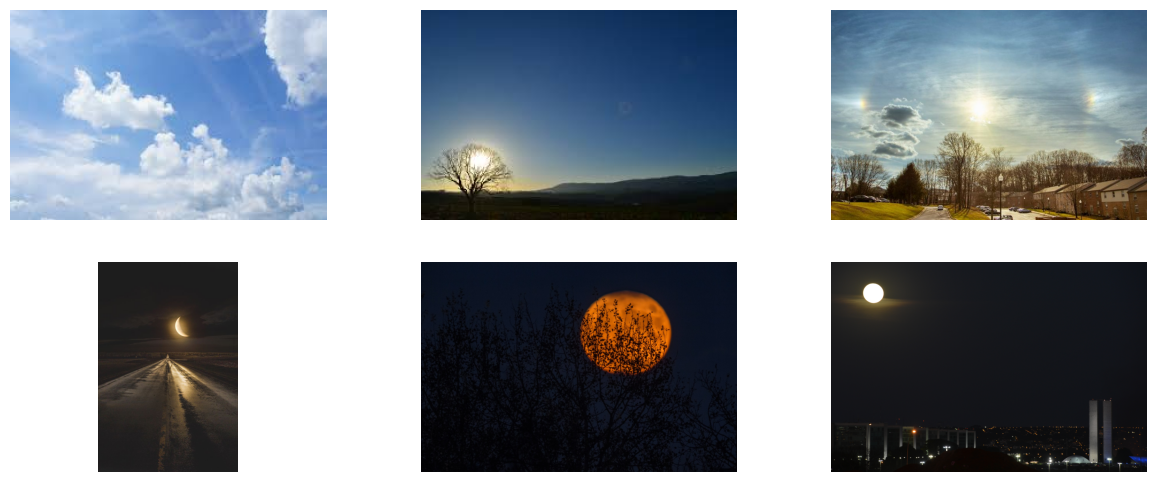

In [4]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:

  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

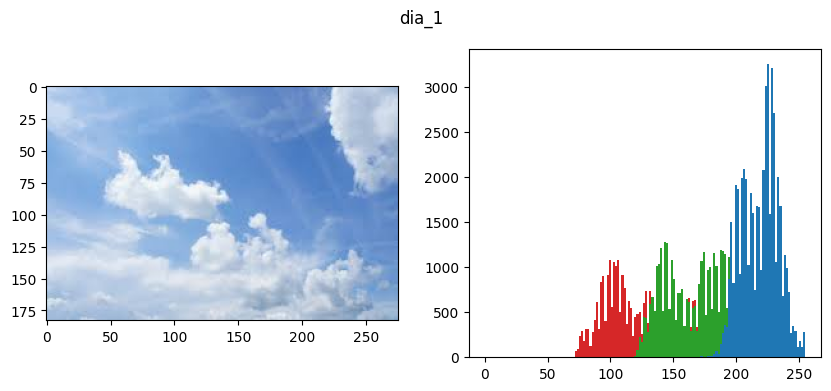

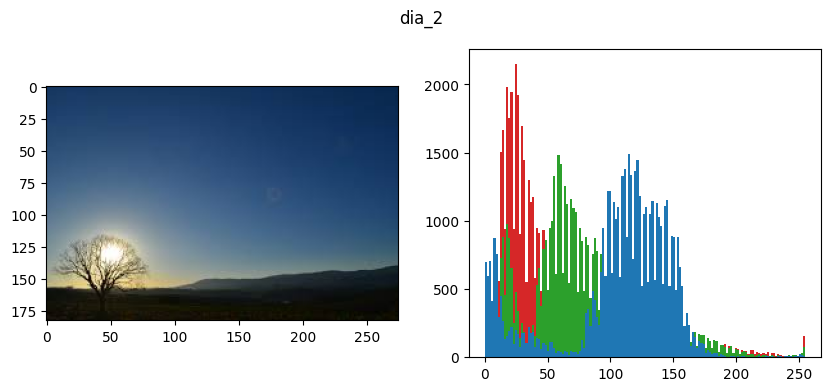

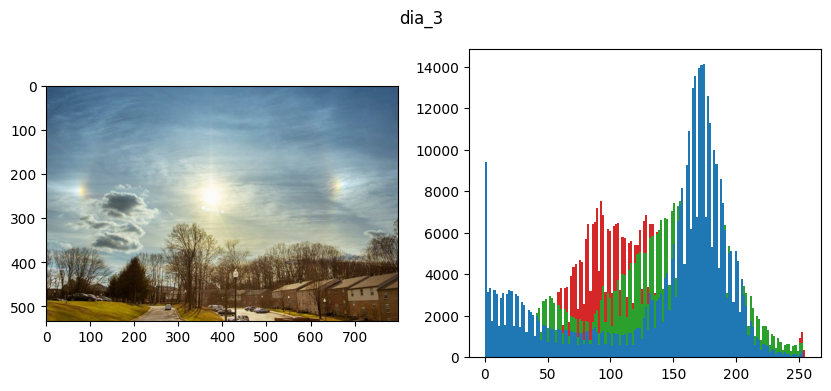

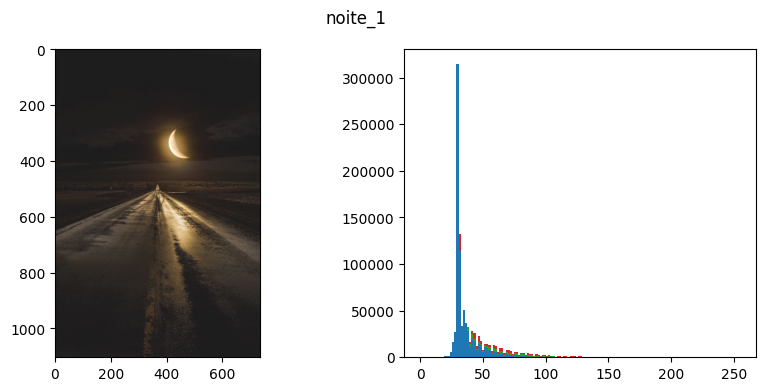

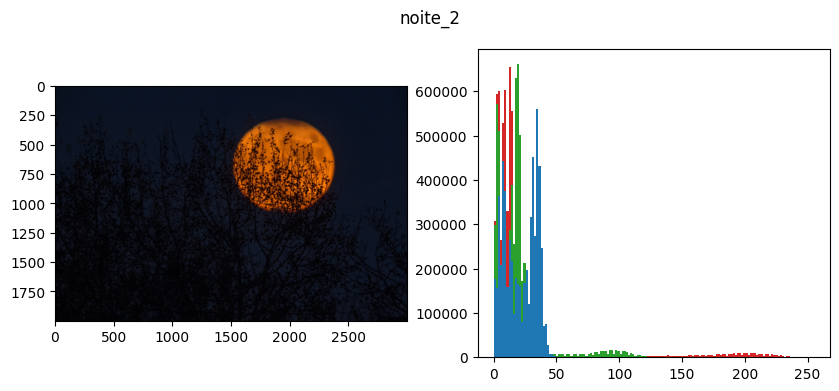

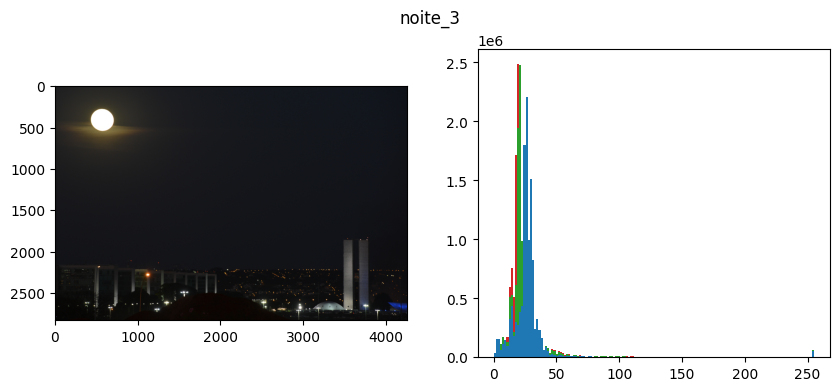

In [5]:
# Experimentando com várias imagens
def plot_hist(h,cor,nbins,bin_edges, ax=None):
    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    if ax is None:
        plt.bar(bin_centers, h, width=w, color=cor)
    else:
        ax.bar(bin_centers, h, width=w, color=cor)

nbins = 150

all_imgs_names = ["dia_1", "dia_2", "dia_3", "noite_1", "noite_2", "noite_3"]

for i in range(len(all_imgs)):
    fig, axes = plt.subplots(1,2, figsize=(10, 4))
    # Plot da imagem
    img = all_imgs[i]
    axes[0].imshow(img)
    # Plot do histograma
    colors = ["tab:red", "tab:green", "tab:blue"]
    for j in range(3):
        h, bin_edges = np.histogram(a=img[:,:,j], bins=nbins, range=(0,255))
        plot_hist(h=h, cor=colors[j], nbins=nbins, bin_edges=bin_edges, ax=axes[1])

    fig.suptitle(all_imgs_names[i])

Comentário: Pelos gráficos, vemos que os histogramas das imagens tiradas durante o dia aparecem mais "espalhados" e com intensidades mais altas, principalmente na banda azul. Isso indica paisagens mais iluminadas, o que é evidenciado pelas imagens diurnas com predominância do céu em tom de azul claro.

Já nas imagens noturnas, os histogramas ficam muito mais concentrados nas baixas intensidades, com as bandas "amontoadas", mostrando predominância de pixels escuros.

Assim, apenas pela análise dos histogramas, é possível distinguir as imagens diurnas das noturnas apresentadas, principalmente pois são paisagens externas com predominância do céu.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

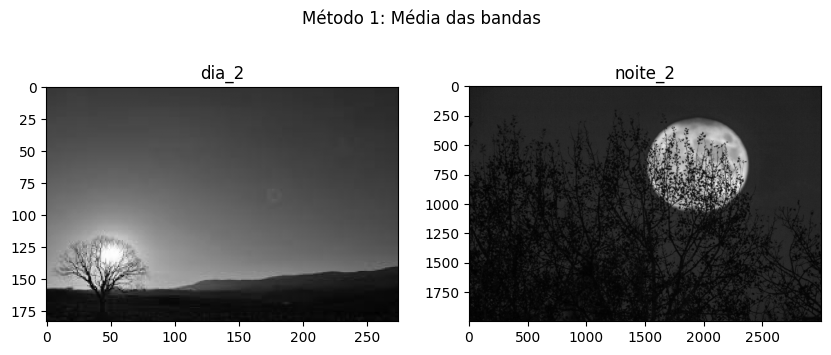

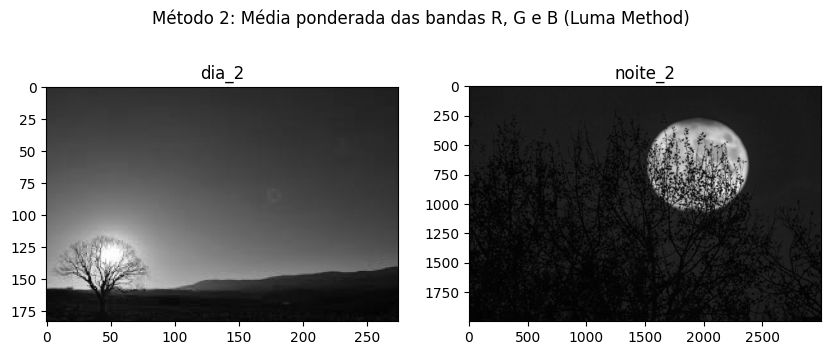

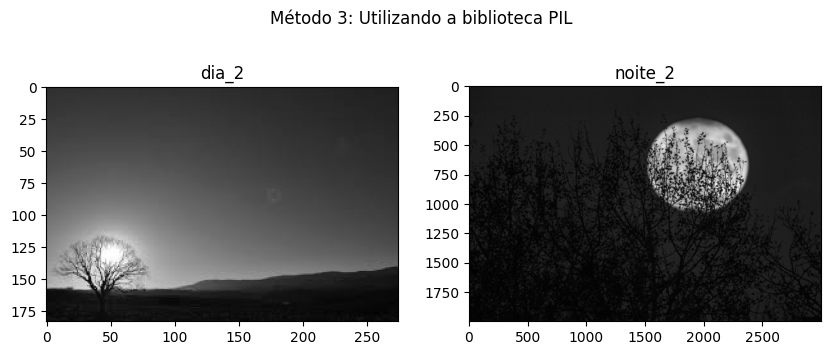

In [6]:
def plot_images(list_images, list_names=None, suptitle=None, figsize=(10, 4)):
    if list_names is not None:
        assert len(list_names) == len(list_images), "A lista de nomes deve ter o mesmo tamanho que a lista de imagens"
    _, axes_imgs = plt.subplots(1, len(list_images), figsize=figsize)
    for i, img in enumerate(list_images):
        ax = axes_imgs[i]
        ax.set_title(f"Imagem {i+1}")
        ax.imshow(img, cmap="gray")
        if list_names is not None:
            ax.set_title(list_names[i])
    if suptitle:
        plt.suptitle(suptitle)
    plt.show()


img_day = all_imgs[1]
img_night = all_imgs[4]
list_names = ["dia_2", "noite_2"]

# Conversão para escala de cinza
methods = [
    "Média das bandas",
    "Média ponderada das bandas R, G e B (Luma Method)",
    "Utilizando a biblioteca PIL"
]

# Método 1: Média das bandas
img_day_gray_mean = np.uint8(np.mean(img_day, axis=2))
img_night_gray_mean = np.uint8(np.mean(img_night, axis=2))

plot_images(
    [img_day_gray_mean, img_night_gray_mean],
    list_names=list_names,
    suptitle=f"Método 1: {methods[0]}",
)


# Método 2: Média ponderada das bandas R, G e B (Luma Method)
# https://en.wikipedia.org/wiki/Luma_(video)
def grayscale_weighted_avg(img: np.ndarray) -> np.ndarray:
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    r_weight = 0.299
    g_weight = 0.587
    b_weight = 0.114
    return np.uint8(r_weight*r + g_weight*g + b_weight*b)

img_day_gray_weighted_avg = grayscale_weighted_avg(img_day)
img_night_gray_weighted_avg = grayscale_weighted_avg(img_night)

plot_images(
    [img_day_gray_weighted_avg, img_night_gray_weighted_avg],
    list_names=list_names,
    suptitle=f"Método 2: {methods[1]}"
)


# Método 3: Utilizando a biblioteca PIL, usando Image.fromarray() e convert("L")
img_day_gray_PIL = Image.fromarray(img_day).convert("L")
img_night_gray_PIL = Image.fromarray(img_night).convert("L")

plot_images(
    [img_day_gray_PIL, img_night_gray_PIL],
    list_names=list_names,
    suptitle=f"Método 3: {methods[2]}"
)

grayscale_images_day = [img_day_gray_mean, img_day_gray_weighted_avg, img_day_gray_PIL]
grayscale_images_night = [img_night_gray_mean, img_night_gray_weighted_avg, img_night_gray_PIL]

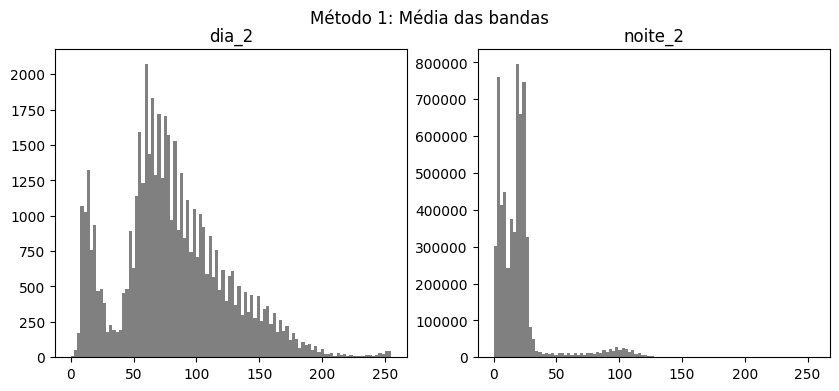

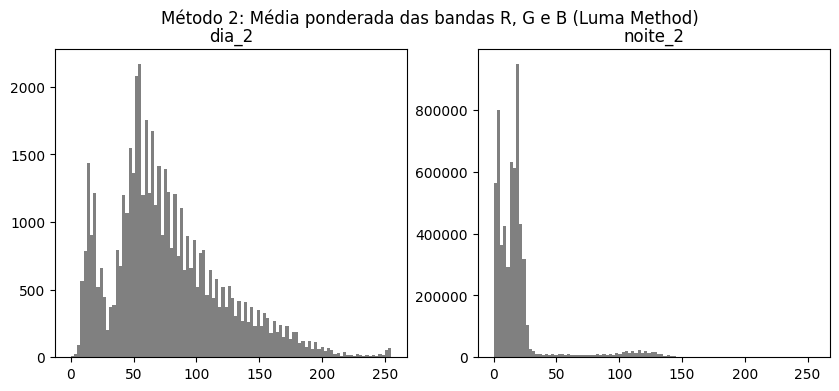

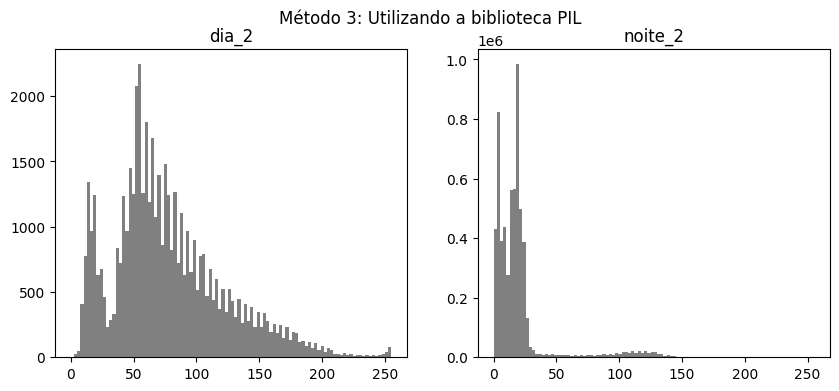

In [7]:
# Montando histogramas para as imagens em escala de cinza
# Como a imagem está em escala de cinza, ela tem apenas um canal, então o histograma é único
nbins = 100

for i in range(len(methods)):
    fig, axes = plt.subplots(1,2, figsize=(10, 4))
    h_day, bin_edges_day = np.histogram(a=grayscale_images_day[i], bins=nbins, range=(0,255))
    h_night, bin_edges_night = np.histogram(a=grayscale_images_night[i], bins=nbins, range=(0,255))
    plot_hist(h_day, cor="gray", nbins=nbins, bin_edges=bin_edges_day, ax=axes[0])
    plot_hist(h_night, cor="gray", nbins=nbins, bin_edges=bin_edges_night, ax=axes[1])
    axes[0].set_title(f"dia_2")
    axes[1].set_title(f"noite_2")
    fig.suptitle(f"Método {i+1}: {methods[i]}")

Após a conversão para tons de cinza, a diferença entre as imagens de dia e de noite continua visível nos histogramas. A imagem diurna mantém valores mais distribuídos e com picos em uma intensidade maior que da imagem noturna. Isso indica que a intensidade global dos pixels ainda é capaz de ajudar a distinguir as duas classes.

No geral, comparando os 3 histogramas de cada imagem, vemos que são bem parecidos, principalmente os métodos 1 e 2, provavelmente pois a função Image.fromarray().convert("L") utiliza o mesmo cálculo do método Luma. Em relação às diferenças, na imagem noite_2, vemos que há um pico um pouco maior na região próxima de zero para os métodos 2 e 3, se comparado com a média simples do método 1. Isso indica que as imagens geradas pelo método 1 são mais claras, por exemplo.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [8]:
def histstat(f):
    """
    f: image in grayscale
    return: vector of 9 statistics
    """
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [9]:
f = all_imgs[0] # dia_1
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
    print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [10]:
f = all_imgs[3] # noite_1
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
    print(f'{feature:.2f}')

43.47
704.20
3.65
16.82
28.00
29.00
33.00
69.00
179.00


Comentário: Comparando os atributos de histograma entre uma imagem de dia e uma de noite, espera-se média e percentis mais baixos para a imagem noturna. Isso se confirma comparando os dois resiltados, já que a imagem de dia deve ser mais "clara" que a imagem de noite.

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

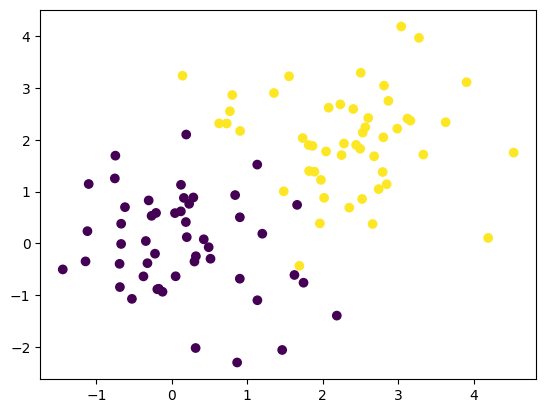

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y)

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



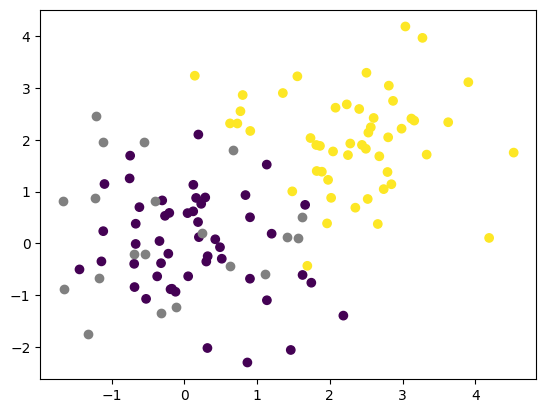

In [12]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [13]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


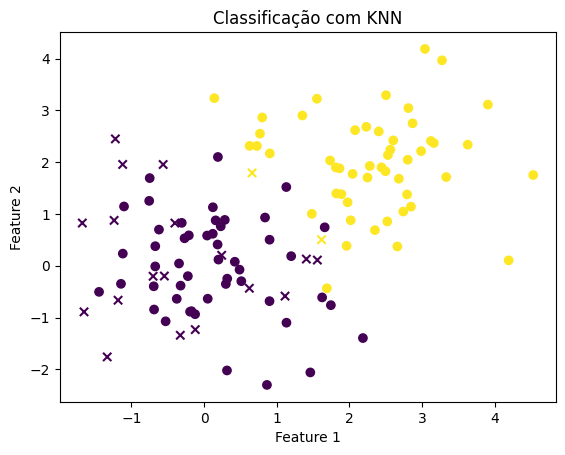

In [14]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [15]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [16]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [17]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f"Shape das imagens: {images_train[0].shape}")

print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

Shape das imagens: (28, 28, 3)
labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

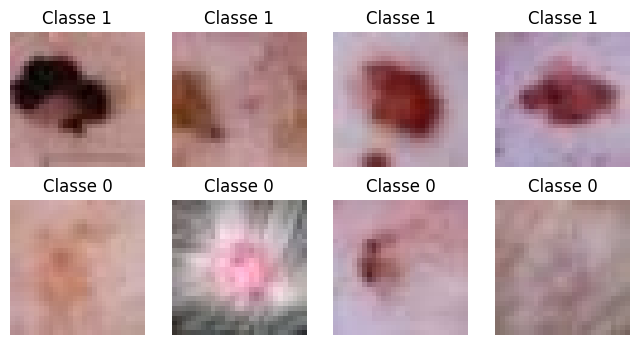

In [18]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
    plt.subplot(2,n_imgs,n+1)
    plt.axis('off')
    tmp = random.randint(0,199)
    plt.imshow(images_train[tmp])
    plt.title(f'Classe {labels_train[tmp]}')

    plt.subplot(2,n_imgs,n+n_imgs+1)
    plt.axis('off')
    tmp = random.randint(200,399)
    plt.imshow(images_train[tmp])
    plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [19]:
def convert_to_grayscale(img: np.ndarray) -> np.ndarray:
    """ Uses the Luma method to convert an RGB image to grayscale """
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    r_weight = 0.299
    g_weight = 0.587
    b_weight = 0.114
    return np.uint8(r_weight*r + g_weight*g + b_weight*b)

def convert_images_to_grayscale(images: list) -> list:
    """ Converts a list of RGB images to grayscale using the Luma method """
    return [convert_to_grayscale(img) for img in images]

images_train_gray = convert_images_to_grayscale(images_train)
images_test_gray = convert_images_to_grayscale(images_test)

def extract_histogram_features(images: list) -> np.ndarray:
    """ Extracts histogram features from a list of grayscale images using the histstat function """
    features = [histstat(img) for img in images]
    return np.array(features)

features_train = extract_histogram_features(images_train_gray)
features_test = extract_histogram_features(images_test_gray)

print(f"features_train:\n{features_train.shape}")
print(f"features_test:\n{features_test.shape}")

features_train:
(400, 9)
features_test:
(100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [20]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

# Treinando o modelo KNN com os dados de treino
knn.fit(features_train, labels_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


=== Avaliando o modelo no dataset de treino === 
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.87      0.77      0.81       200
    Melanoma       0.79      0.89      0.83       200

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



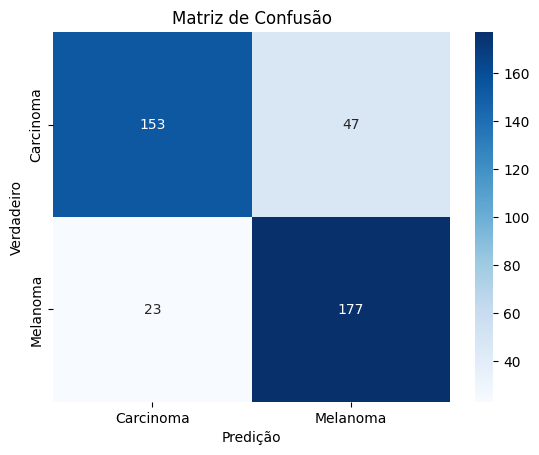

=== Avaliando o modelo no dataset de teste ===
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.84      0.74      0.79        50
    Melanoma       0.77      0.86      0.81        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



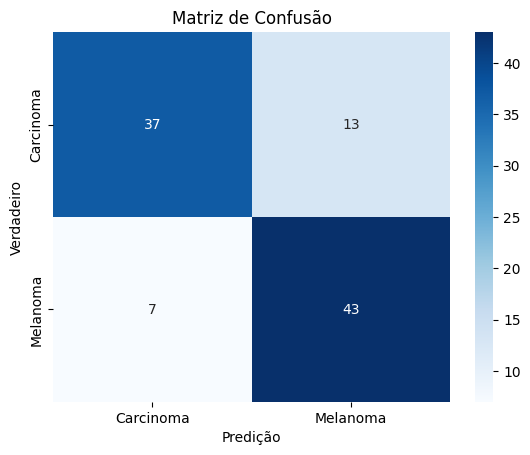

In [21]:
class_names = {
    0: "Carcinoma",
    1: "Melanoma"
}

def evaluate_model(model, features, labels):
    """ Avalia o modelo utilizando as métricas de acurácia, precisão, recall e F1-score """
    predictions = model.predict(features)

    # Relatório de classificação
    # Inclui as métricas de acurácia, precisão, recall e F1-score para cada classe
    report = classification_report(labels, predictions, target_names=class_names.values())
    print(f"Relatório de classificação:\n\n{report}")

    # Matriz de confusão
    fig, ax = plt.subplots()
    cm = confusion_matrix(labels, predictions)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names.values(), yticklabels=class_names.values())
    plt.xlabel("Predição")
    plt.ylabel("Verdadeiro")
    plt.title("Matriz de Confusão")
    plt.show()

print(f"=== Avaliando o modelo no dataset de treino === ")
evaluate_model(knn, features_train, labels_train)
    
print(f"=== Avaliando o modelo no dataset de teste ===")
evaluate_model(knn, features_test, labels_test)

**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

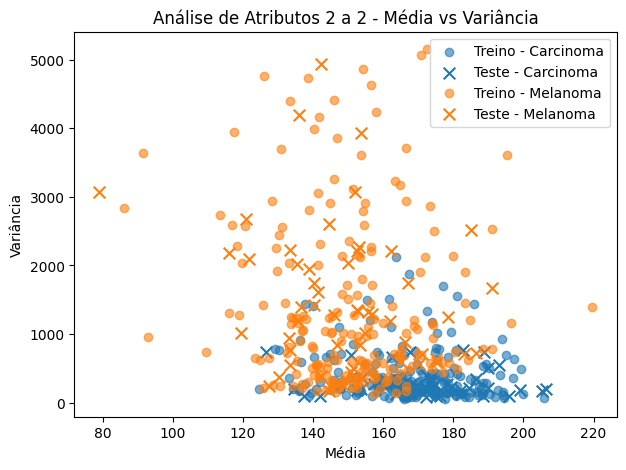

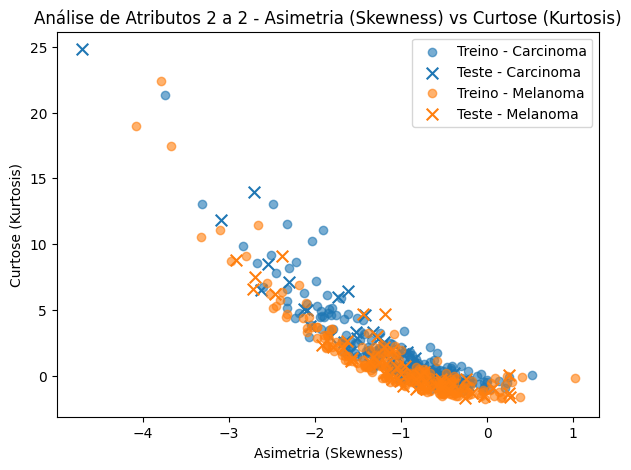

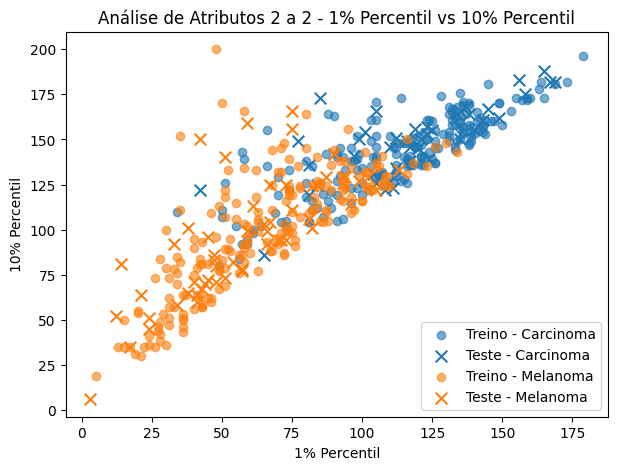

In [22]:
colors = {0: "tab:blue", 1: "tab:orange"}

atributes = {
    0: "Média",
    1: "Variância",
    2: "Asimetria (Skewness)",
    3: "Curtose (Kurtosis)",
    4: "1% Percentil",
    5: "10% Percentil",
    6: "50% Percentil",
    7: "90% Percentil",
    8: "99% Percentil"
}

predictions_test = knn.predict(features_test)

def attribute_analysis_2x2(idx_x, idx_y, class_names):
    plt.figure(figsize=(7, 5))
    for c in [0, 1]:    # Iterando sobre as classes
        idx_train = np.array(labels_train) == c        # labels de treino para a classe c
        idx_test = np.array(predictions_test) == c    # resultados do teste para a classe c

        plt.scatter(
            features_train[idx_train, idx_x], features_train[idx_train, idx_y],
            color=colors[c], marker="o", alpha=0.6,
            label=f"Treino - {class_names[c]}"
        )
        plt.scatter(
            features_test[idx_test, idx_x], features_test[idx_test, idx_y],
            color=colors[c], marker="x", s=70,
            label=f"Teste - {class_names[c]}"
        )

    plt.xlabel(f"{atributes[idx_x]}")
    plt.ylabel(f"{atributes[idx_y]}")
    plt.title(f"Análise de Atributos 2 a 2 - {atributes[idx_x]} vs {atributes[idx_y]}")
    plt.legend()
    plt.show()

# Analisando os atributos de Média e Variância
attribute_analysis_2x2(0, 1, class_names=class_names)

# Analisando os atributos de Skewness e Kurtosis
attribute_analysis_2x2(2, 3, class_names=class_names)

# Analisando os atributos de Skewness e Kurtosis
attribute_analysis_2x2(4, 5, class_names=class_names)

Nos gráficos 2 a 2, é esperado algum agrupamento por classe, mas também sobreposição significativa entre carcinoma e melanoma. No gráfico Média vs Variância, por exemplo, são observados algumas diferenças, com a classe Melanoma tendo valores de variância bem mais espaçados e maiores que a classe Carcinoma. O gráfico 1% vs 10% também mostra uma leve diferença mas com bastante sobreposição.

Já em relação ao gráfico skewness vs kurtosis, os dados estão bem sobrepostos, com pouca diferença visível. Isso nos dá uma dica de quais atributos serão relevantes para o treinamento do modelo.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta:

No geral, a baseline apresentou um desempenho razoável, mas ainda apresentando confusões entre as duas classes, principalmente ao prever corretamente a classe carcinoma. Dentre as modificações, pode-se tentar ajustar os parâmetros de treino do KNN, além de fazer transformações nas imagens de treino e teste.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

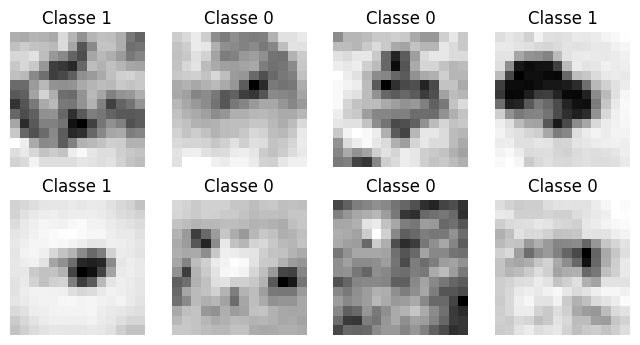

In [23]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GridSearchCV

# 1: Redimensionamento das imagens para 14x14 usando a biblioteca PIL
def resize_images(images: list, size=(14, 14)) -> list:
    """ Redimensiona uma lista de imagens para o tamanho especificado usando a biblioteca PIL """
    # TODO: definir o método de interpolação. Usando o default do PIL: BICUBIC
    return [np.array(Image.fromarray(img).resize(size, resample=Image.Resampling.BICUBIC), dtype=np.uint8) for img in images]

# Aplicando o redimensionamento de 14x14 nas imagens de treino e teste
images_train_resized = resize_images(images_train_gray, size=(14, 14))
images_test_resized = resize_images(images_test_gray, size=(14, 14))

# Mostrando algumas imagens redimensionadas
n = 4
fig, axs = plt.subplots(2,n,figsize=(8, 4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.axis('off')
    tmp = random.randint(0,199)
    plt.imshow(images_train_resized[tmp], cmap="gray")
    plt.title(f'Classe {labels_train[tmp]}')

    plt.subplot(2,n,i+n+1)
    plt.axis('off')
    tmp = random.randint(200,399)
    plt.imshow(images_train_resized[tmp], cmap="gray")
    plt.title(f'Classe {labels_train[tmp]}')
plt.show()

# Extraindo features das imagens redimensionadas
X_train_resized = extract_histogram_features(images_train_resized)
X_test_resized = extract_histogram_features(images_test_resized)
y_train = labels_train
y_test = labels_test

In [24]:
# 2:Seleção de atributos usando SelectKBest
feature_names = [
    "Media",
    "Variancia",
    "Assimetria",
    "Curtose",
    "Percentil_1",
    "Percentil_10",
    "Percentil_50",
    "Percentil_90",
    "Percentil_99",
]

# O SelectKBest seleciona os k melhores atributos com base na scoring function fornecida (neste caso, mutual_info_classif)
selector = SelectKBest(score_func=mutual_info_classif, k=6)
# Aqui, o fit do selector é feito apenas no conjunto de treino
# Depois a transformação é aplicada tanto no treino quanto no teste
X_train_sel = selector.fit_transform(X_train_resized, y_train)
X_test_sel = selector.transform(X_test_resized)

# Mostrando os atributos selecionados
selected_idx = selector.get_support(indices=True)
selected_names = [feature_names[i] for i in selected_idx]
print(f"Atributos selecionados: {selected_names}")

Atributos selecionados: ['Media', 'Variancia', 'Curtose', 'Percentil_1', 'Percentil_10', 'Percentil_50']


Melhor k: 7
=== Avaliando o modelo otimizado no dataset de teste ===
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.91      0.78      0.84        50
    Melanoma       0.81      0.92      0.86        50

    accuracy                           0.85       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.85      0.85       100



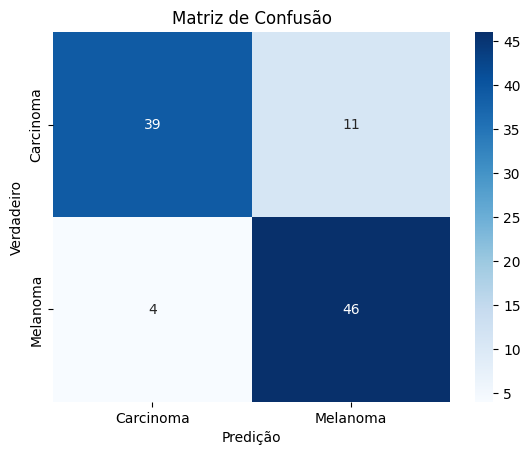

In [25]:
# 3: Explorando o melhor valor de k para o KNN usando GridSearchCV
def train_knn_with_grid_search(X_train, y_train):
    param_grid = {
        "n_neighbors": np.arange(1, 20, 1)
    }
    grid = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_k = grid.best_params_["n_neighbors"]
    best_estimator = grid.best_estimator_
    print(f"Melhor k: {best_k}")
    return best_estimator

# Treinando o modelo KNN com GridSearchCV para encontrar o melhor k
knn = train_knn_with_grid_search(X_train_sel, y_train)

# Avaliando o modelo
print(f"=== Avaliando o modelo otimizado no dataset de teste ===")
predictions_test = knn.predict(X_test_sel)
evaluate_model(knn, X_test_sel, y_test)

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [26]:
# Redimensionando imagens coloridas para 14x14
images_train_rgb_resized = resize_images(images_train, size=(14, 14))
images_test_rgb_resized = resize_images(images_test, size=(14, 14))

def extract_rgb_histogram_features(images):
    """
    Extrai histstat de cada canal R, G, B e concatena (27 features por imagem)
    """
    features = []
    for img in images:
        # Extrai histstat para cada canal
        r_stats = histstat(img[:, :, 0])
        g_stats = histstat(img[:, :, 1])
        b_stats = histstat(img[:, :, 2])
        # Concatena os 27 features (9 de cada canal)
        combined = np.concatenate([r_stats, g_stats, b_stats])
        features.append(combined)
    return np.array(features)

X_train_rgb = extract_rgb_histogram_features(images_train_rgb_resized)
X_test_rgb = extract_rgb_histogram_features(images_test_rgb_resized)
y_train = labels_train
y_test = labels_test

print(f"X_train: {X_train_rgb.shape}")
print(f"X_test: {X_test_rgb.shape}")

X_train: (400, 27)
X_test: (100, 27)


Melhor k: 19
=== Avaliando o modelo otimizado no dataset de teste ===
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.88      0.84      0.86        50
    Melanoma       0.85      0.88      0.86        50

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



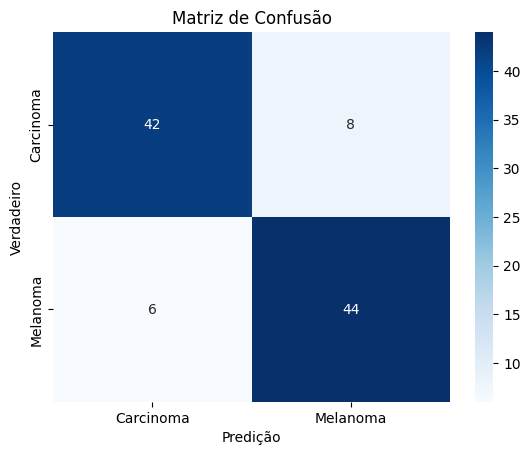

In [27]:
# Sem seleção de atributos (usa os 27 features RGB)
knn_all_attr = train_knn_with_grid_search(X_train_rgb, y_train)

# Avaliando o modelo
print(f"=== Avaliando o modelo otimizado no dataset de teste ===")
evaluate_model(knn_all_attr, X_test_rgb, y_test)

Atributos selecionados: ['R_Media', 'R_Variancia', 'R_Per1', 'R_Per10', 'R_Per50', 'R_Per90', 'G_Media', 'G_Variancia', 'G_Curtose', 'G_Per1', 'G_Per10', 'G_Per50', 'B_Media', 'B_Variancia', 'B_Curtose', 'B_Per1', 'B_Per10', 'B_Per50']
Melhor k: 14
=== Avaliando o modelo otimizado no dataset de teste ===
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.88      0.86      0.87        50
    Melanoma       0.86      0.88      0.87        50

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



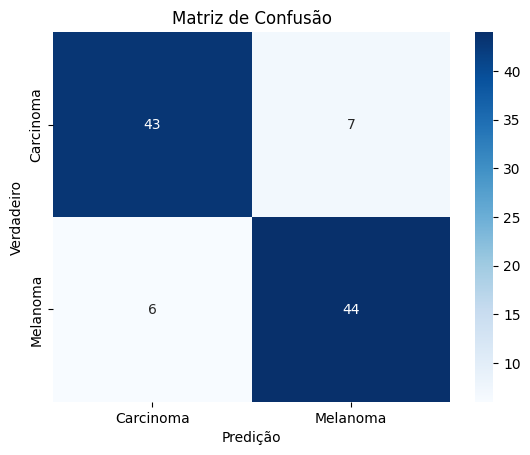

In [28]:
# Com selecao de atributos (mantém k dos 27 features)
k_features_rgb = 18
selector_rgb = SelectKBest(score_func=mutual_info_classif, k=k_features_rgb)
X_train_rgb_sel = selector_rgb.fit_transform(X_train_rgb, y_train)
X_test_rgb_sel = selector_rgb.transform(X_test_rgb)

# Mapeaando quais features foram selecionadas
rgb_feature_names = [
    "R_Media", "R_Variancia", "R_Assimetria", "R_Curtose", "R_Per1", "R_Per10", "R_Per50", "R_Per90", "R_Per99",
    "G_Media", "G_Variancia", "G_Assimetria", "G_Curtose", "G_Per1", "G_Per10", "G_Per50", "G_Per90", "G_Per99",
    "B_Media", "B_Variancia", "B_Assimetria", "B_Curtose", "B_Per1", "B_Per10", "B_Per50", "B_Per90", "B_Per99",
]
selected_idx_rgb = selector_rgb.get_support(indices=True)
selected_names_rgb = [rgb_feature_names[i] for i in selected_idx_rgb]
print(f"Atributos selecionados: {selected_names_rgb}")

knn_rgb_sel = train_knn_with_grid_search(X_train_rgb_sel, y_train)
print(f"=== Avaliando o modelo otimizado no dataset de teste ===")
evaluate_model(knn_rgb_sel, X_test_rgb_sel, y_test)

In [29]:
# Analise por canal individual (R, G, B)
print("\n\n=== ANALISE POR CANAL (R, G, B) ===")
for idx, channel_name in enumerate(["R", "G", "B"]):
    # Extraindo apenas o canal idx para as features de treino e teste
    images_channel_train = [img[:,:,idx] for img in images_train_rgb_resized]
    images_channel_test = [img[:,:,idx] for img in images_test_rgb_resized]
    features_channel = extract_histogram_features(images_channel_train)
    test_channel = extract_histogram_features(images_channel_test)
    y_train = labels_train
    y_test = labels_test
    # Treinando o modelo KNN para o canal específico
    knn_channel = train_knn_with_grid_search(features_channel, y_train)
    y_pred_ch = knn_channel.predict(test_channel)
    # Avaliando o modelo para o canal específico
    acc = accuracy_score(y_test, y_pred_ch)
    f1 = f1_score(y_test, y_pred_ch)
    print(f"{channel_name}: F1={f1:.3f}")



=== ANALISE POR CANAL (R, G, B) ===
Melhor k: 17
R: F1=0.826
Melhor k: 3
G: F1=0.769
Melhor k: 5
B: F1=0.846


A extração foi feita por canal RGB: histstat em R, G e B separadamente, com concatenação (27 atributos por imagem). Depois, o processo de melhoria foi repetido com redimensionamento, busca de k e seleção de atributos, além da análise por canal individual. O desempenho foi ligeiramente melhor que o treino com as imagens em escala de cinza.

Na análise por banda, vemos que a banda B (azul) possui um melhor desempenho se comparado às outras, indicando que seus atributos são mais relevantes para o modelo extrair corretamente as features.

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [30]:
from skimage.feature import graycomatrix, graycoprops

# Extrai atributos de textura GLCM de uma imagem em escala de cinza
# A GLCM (Gray-Level Co-occurrence Matrix) mede como pares de pixels com determinados
# valores de intensidade ocorrem juntos numa dada direção e distância.
# Parâmetros:
#   - distances=[1]: analisa pares de pixels vizinhos (distância 1 devido às imagens pequenas 14x14)
#   - angles: 4 direções (0°, 45°, 90°, 135°) para capturar padrões em diferentes orientações
#   - levels=256: considerando 256 níveis de cinza (0-255)
#   - symmetric=True: GLCM simétrica
#   - normed=True: normaliza a GLCM para que os valores sejam probabilidades

# São extraídas 5 propriedades (médias sobre as 4 direções):
#   - Contraste: mede variação local de intensidade (textura rugosa -> alto)
#   - Dissimilaridade: similar ao contraste, mas linear (não quadrática)
#   - Homogeneidade: mede proximidade dos elementos à diagonal da GLCM (textura suave -> alto)
#   - Energia: mede uniformidade da textura (textura uniforme -> alto)
#   - Correlação: mede dependência linear entre pares de pixels

def extract_glcm_features(images):
    features = []
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
    for img in images:
        img_uint8 = np.uint8(np.clip(img, 0, 255))
        glcm = graycomatrix(img_uint8, distances=[1], angles=angles, levels=256, symmetric=True, normed=True)
        # Média sobre as 4 direções para cada propriedade
        feat = [graycoprops(glcm, prop).mean() for prop in props]
        features.append(feat)
    return np.array(features)

# Usar as imagens 14x14 já disponíveis
X_train_glcm = extract_glcm_features(images_train_resized)
X_test_glcm = extract_glcm_features(images_test_resized)
y_train = labels_train
y_test = labels_test

print(f"X_train: {X_train_glcm.shape}")
print(f"X_test: {X_test_glcm.shape}")

X_train: (400, 5)
X_test: (100, 5)


Melhor k: 19
Relatório de classificação:

              precision    recall  f1-score   support

   Carcinoma       0.79      0.76      0.78        50
    Melanoma       0.77      0.80      0.78        50

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



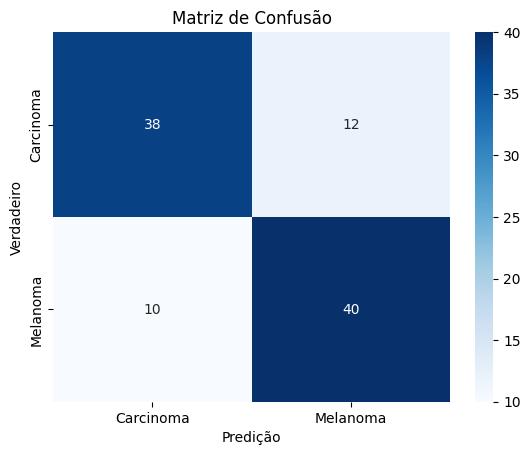

In [31]:
knn_glcm = train_knn_with_grid_search(X_train_glcm, y_train)
evaluate_model(knn_glcm, X_test_glcm, y_test)